 # Bijplaatsing Detection met YOLOv8n
 
 Dit notebook traint een YOLOv8-classificatiemodel om te bepalen of een container **met bijplaatsing** of **zonder bijplaatsing** is afgebeeld.
 
 Dataset locatie:
 ```
 C:\Users\rtvan\Documents\GitHub\AI-Waste_Vision_POC\Bijplaatsing Detection\dataset
 ```
 Verwachte folderstructuur:
 ```
 dataset/
   train/
     met_bijplaatsing/
     zonder_bijplaatsing/
   val/
     met_bijplaatsing/
     zonder_bijplaatsing/
 ```
 We splitsen de originele dataset automatisch 80/20 in train en val.


In [8]:
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from tensorflow.keras.preprocessing import image
from ultralytics import YOLO
%matplotlib inline


# Data preparation

Dataset voorbereiden, splisen van afbeeldingen in 80% train en 20% val.

In [1]:
import os, shutil, random

# Brondata
source_with = r"C:/Users/rtvan/Documents/GitHub/AI-Waste_Vision_POC/Container Detection/Images/Containers/Met bijplaatsing"
source_without = r"C:/Users/rtvan/Documents/GitHub/AI-Waste_Vision_POC/Container Detection/Images/Containers/Zonder bijplaatsing"

# Dataset map (nieuw)
dataset_root = r"C:/Users/rtvan/Documents/GitHub/AI-Waste_Vision_POC/Bijplaatsing Detection/dataset"

# Definieer klassen
classes = {
    "met_bijplaatsing": source_with,
    "zonder_bijplaatsing": source_without
}

# Maak folders voor train/val
for split in ["train", "val"]:
    for cls in classes.keys():
        os.makedirs(os.path.join(dataset_root, split, cls), exist_ok=True)

# 80/20 data split
split_ratio = 0.8

for cls, src in classes.items():
    images = [f for f in os.listdir(src) if f.lower().endswith((".jpg", ".png", ".jpeg"))]
    random.shuffle(images)

    split_point = int(len(images) * split_ratio)
    train_imgs = images[:split_point]
    val_imgs = images[split_point:]

    for f in train_imgs:
        shutil.copy(os.path.join(src, f), os.path.join(dataset_root, "train", cls))

    for f in val_imgs:
        shutil.copy(os.path.join(src, f), os.path.join(dataset_root, "val", cls))

print("Dataset aangemaakt!")


Dataset aangemaakt!


# Modeling

Trainen model YOLOv8n, kiezen weer voor nano voor snelle training en is gebleken uit herkennen container dat deze prima werkt.

In [2]:
# YOLOv8n
model = YOLO("yolov8n-cls.pt")

results = model.train(
    data=dataset_root,
    epochs=10,
    batch=32,
    imgsz=224,
    lr0=0.001,
    name="bijplaatsing_classification"
)

print("Training klaar!")

Ultralytics 8.3.232  Python-3.11.9 torch-2.9.1+cpu CPU (12th Gen Intel Core i7-12650H)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:/Users/rtvan/Documents/GitHub/AI-Waste_Vision_POC/Bijplaatsing Detection/dataset, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=bijplaatsing_classification, nbs=64, nms=False, opset=None, optimize=False, 

## Validatie en evaluatie

In [4]:
model = YOLO("runs/classify/bijplaatsing_classification/weights/best.pt")

val_dir = os.path.join(dataset_root, "val")
class_names = ["met_bijplaatsing", "zonder_bijplaatsing"]

# Maak lijsten van images en labels
val_images = []
y_true = []

for i, cls in enumerate(class_names):
    cls_dir = os.path.join(val_dir, cls)
    for f in os.listdir(cls_dir):
        val_images.append(os.path.join(cls_dir, f))
        y_true.append(i)

y_true = np.array(y_true)

# predict
y_pred = []
for img_path in val_images:
    pred = model.predict(img_path, verbose=False)[0]
    y_pred.append(pred.probs.top1)

y_pred = np.array(y_pred)

# metrics
print("Accuracy:", (y_true == y_pred).mean())
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1:", f1_score(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
print(cm)


Accuracy: 0.9185393258426966
Precision: 0.9234972677595629
Recall: 0.9184782608695652
F1: 0.9209809264305178
[[158  14]
 [ 15 169]]


## Confusion Matrix visualiseren

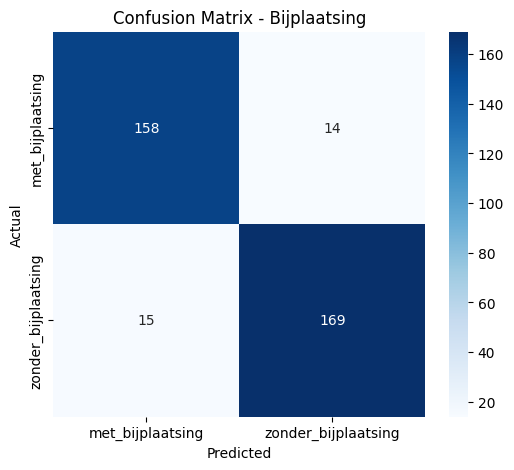

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Bijplaatsing")
plt.show()


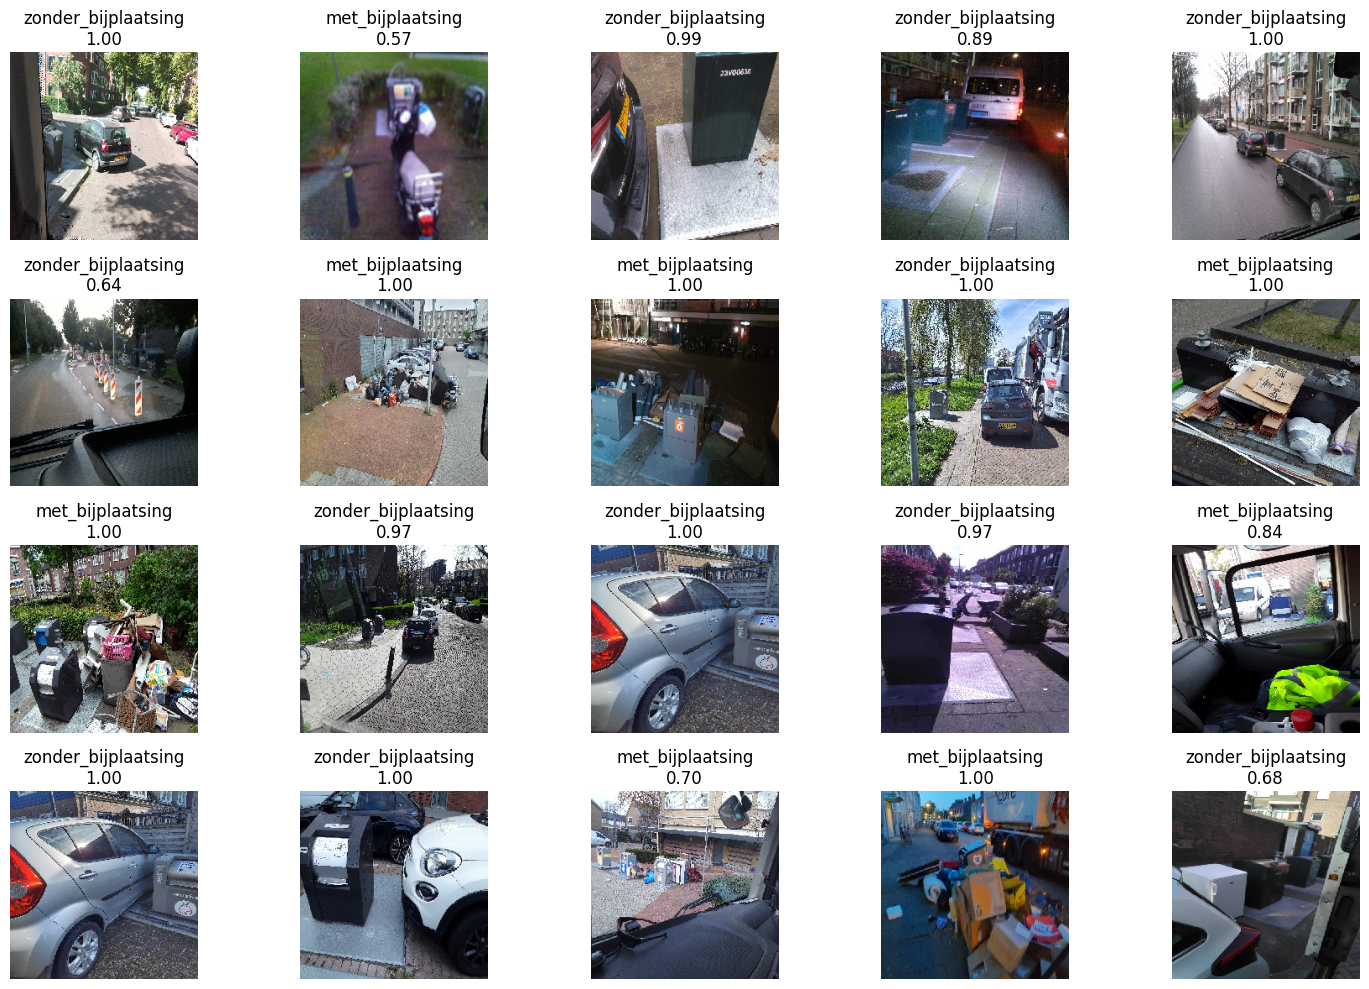

In [11]:
sample_imgs = random.sample(val_images, 20)

fig = plt.figure(figsize=(15, 10))

for idx, img_path in enumerate(sample_imgs):
    result = model.predict(img_path, verbose=False)[0]
    pred_idx = result.probs.top1
    conf = float(result.probs.top1conf)

    img = image.load_img(img_path, target_size=(224,224))

    ax = fig.add_subplot(4, 5, idx+1)
    ax.imshow(img)
    ax.set_title(f"{class_names[pred_idx]}\n{conf:.2f}")
    ax.axis('off')

plt.tight_layout()
plt.show()

False Negatives (gemist bijplaatsing): 14
False Positives (onterecht bijplaatsing voorspeld): 15


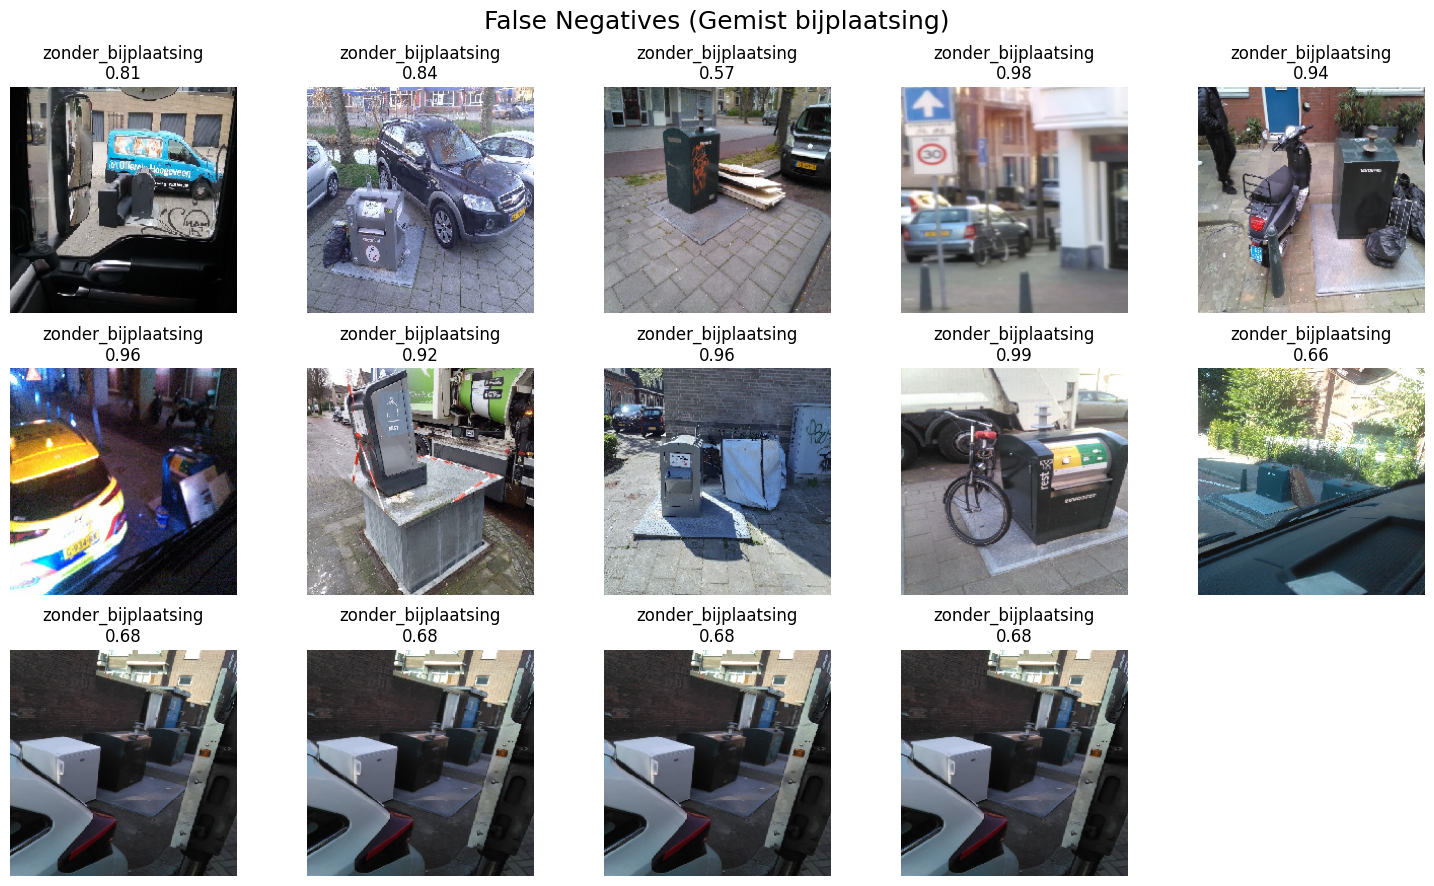

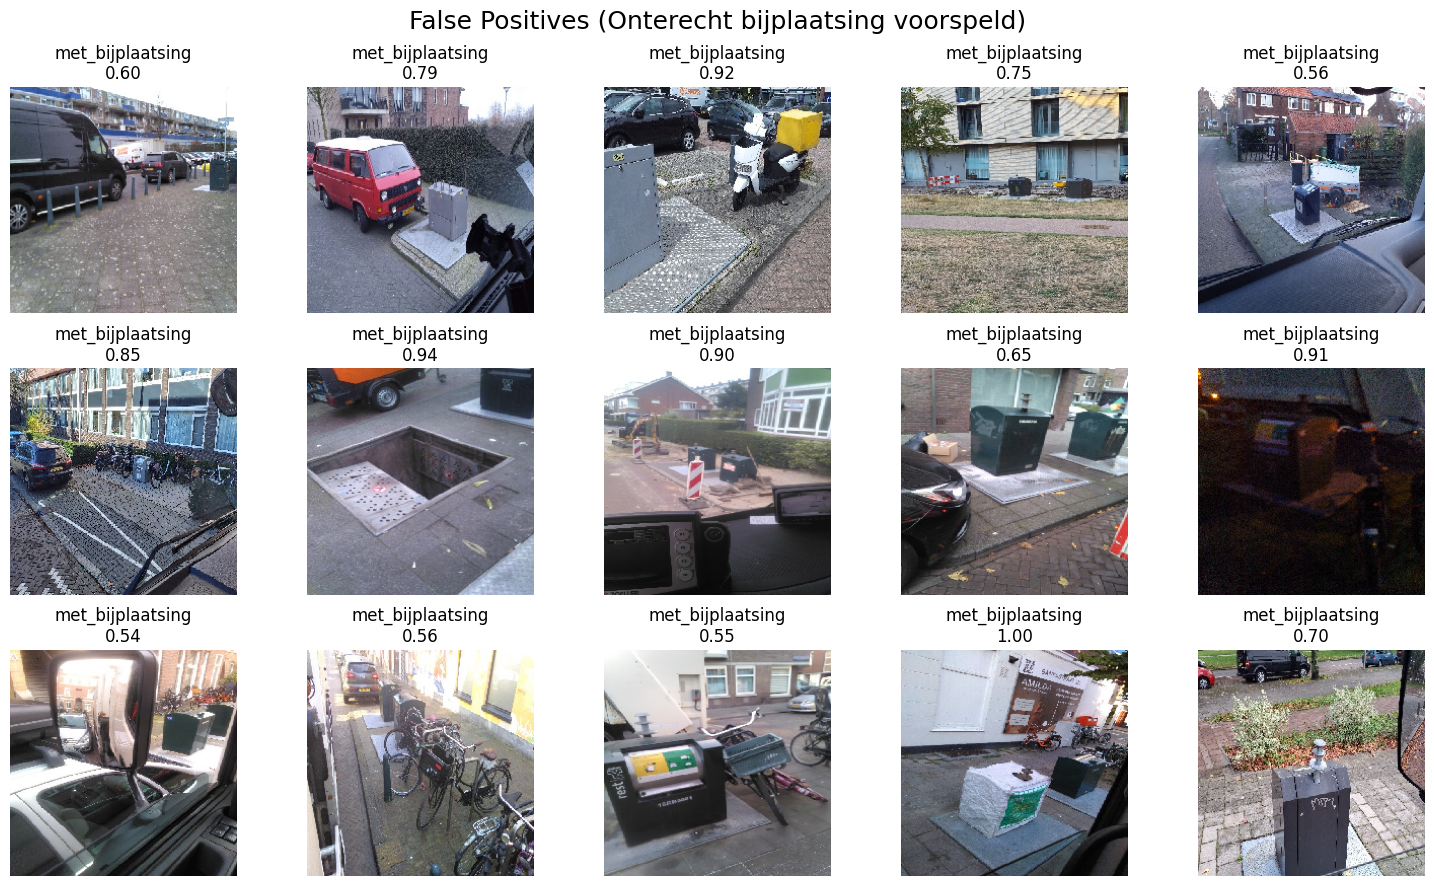

In [12]:

# Maak lijsten voor fouten
false_positives = []   # voorspeld "met bijplaatsing" maar is "zonder bijplaatsing"
false_negatives = []   # voorspeld "zonder bijplaatsing" maar is "met bijplaatsing"

for i, img_path in enumerate(val_images):
    result = model.predict(img_path, verbose=False)[0]
    pred_idx = result.probs.top1
    pred_conf = float(result.probs.top1conf)
    
    if y_true[i] == 0 and pred_idx == 1:
        false_negatives.append((img_path, pred_idx, pred_conf))  # gemist bijplaatsing
    elif y_true[i] == 1 and pred_idx == 0:
        false_positives.append((img_path, pred_idx, pred_conf))  # onterecht bijplaatsing

print(f"False Negatives (gemist bijplaatsing): {len(false_negatives)}")
print(f"False Positives (onterecht bijplaatsing voorspeld): {len(false_positives)}")

# Functie om voorbeelden te plotten
def plot_examples(examples, title, max_imgs=20):
    if len(examples) == 0:
        print(f"Geen {title.lower()} gevonden.")
        return

    examples = examples[:max_imgs]
    cols = 5
    rows = int(np.ceil(len(examples) / cols))
    
    fig = plt.figure(figsize=(15, 3 * rows))
    plt.suptitle(title, fontsize=18)
    
    for i, (img_path, pred, conf) in enumerate(examples):
        img_loaded = image.load_img(img_path, target_size=(224, 224))
        ax = fig.add_subplot(rows, cols, i + 1)
        ax.imshow(img_loaded)
        ax.set_title(f"{class_names[pred]}\n{conf:.2f}")
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# Plot false negatives en false positives
plot_examples(false_negatives, "False Negatives (Gemist bijplaatsing)")
plot_examples(false_positives, "False Positives (Onterecht bijplaatsing voorspeld)")



 ### Conclusie
 
 - Het YOLOv8n-model kan containers met en zonder bijplaatsing detecteren.
 - False positives en false negatives geven inzicht in de moeilijkste voorbeelden.
 - Volgende stappen:
   - Mogelijk class balancing toevoegen
   - Augmentaties voor meer robuustheid
   - Vergelijk YOLOv8n met grotere modellen (s, m) voor hogere nauwkeurigheid